# 阶段 2：最小 Decoder-only Transformer

本 Notebook 调用 `src/llm_learning/tinygpt` 中自行实现的 TinyGPT，并沿一次 forward 观察完整张量流：

```text
input_ids [B,T]
→ token embedding + position embedding [B,T,D]
→ Q/K/V [B,H,T,head_dim]
→ attention scores [B,H,T,T]
→ Transformer blocks [B,T,D]
→ logits [B,T,V]
→ cross entropy loss []
```

阶段 2 使用 learned absolute position embedding、multi-head causal self-attention、GELU MLP、Pre-LayerNorm 和 residual connection。RoPE、GQA、FlashAttention、KV Cache、MoE 与 LoRA 留到后续阶段。

## 0. 前置概念

### 0.1 三个核心维度

| 符号 | 含义 |
| --- | --- |
| `B` | 一个 batch 中的序列数量 |
| `T` | 每条序列的 token 数量 |
| `D` | 每个序列位置的 hidden-state 宽度 |

Token ID 的形状为 `[B,T]`。Embedding 把每个 ID 替换为长度 `D` 的向量，形状变为 `[B,T,D]`。

### 0.2 Linear 只变换最后一维

`nn.Linear(D, 3D)` 会把 `[B,T,D]` 变为 `[B,T,3D]`。`B` 和 `T` 保持不变，每个位置使用同一组 Linear 参数。

### 0.3 矩阵乘法只计算最后两个维度

Q 的形状为 `[B,H,T,head_dim]`，K 转置后的形状为 `[B,H,head_dim,T]`：

```text
[B,H,T,head_dim] @ [B,H,head_dim,T]
→ [B,H,T,T]
```

`B` 和 `H` 负责分组，每组独立完成一次 `T × head_dim` 与 `head_dim × T` 的矩阵乘法。

### 0.4 已有知识与本阶段新内容

阶段 0～1 已经覆盖 shifted targets、logits、cross entropy、embedding、forward、backward 和 optimizer。Position embedding、多头 attention、residual connection、LayerNorm 与 MLP 会在本 Notebook 中逐步学习。

## 1. 导入实现

In [1]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

from llm_learning.bigram.data import (
    NextTokenDataset,
    download_tiny_shakespeare,
    split_token_ids,
)
from llm_learning.bigram.tokenizer import CharacterTokenizer
from llm_learning.bigram.train import (
    infinite_batches,
    make_evaluation_loader,
    make_loader,
)
from llm_learning.tinygpt.config import (
    ModelConfig,
    TrainConfig,
)
from llm_learning.tinygpt.model import TinyGPT
from llm_learning.tinygpt.train import evaluate

# 固定模型初始化，并选择实际计算设备。
torch.manual_seed(2026)
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print("device:", device)

device: cuda


## 2. 准备一个小 batch

字符 tokenizer、顺序切分和 next-token Dataset 沿用阶段 1。本阶段把注意力放在模型 forward。观察用 batch 取 `B=4`、`T=16`。模型的 `block_size=128`，因此一次 forward 最多接收 128 个 token。

In [2]:
data_path = Path("../data/tinyshakespeare/input.txt")
download_tiny_shakespeare(data_path)
text = data_path.read_text(encoding="utf-8")
tokenizer = CharacterTokenizer.from_text(text)
token_ids = tokenizer.encode(text)
train_ids, validation_ids, _ = split_token_ids(token_ids)

# 使用固定顺序的小 batch 观察 next-token 样本。
observation_dataset = NextTokenDataset(
    train_ids,
    block_size=16,
)
observation_loader = make_loader(
    dataset=observation_dataset,
    batch_size=4,
    shuffle=False,
    device=torch.device("cpu"),
)
batch_inputs, batch_targets = next(iter(observation_loader))

print("input_ids shape:", tuple(batch_inputs.shape))
print("targets shape:", tuple(batch_targets.shape))
print("first input:", repr(tokenizer.decode(batch_inputs[0].tolist())))
print("first target:", repr(tokenizer.decode(batch_targets[0].tolist())))

input_ids shape: (4, 16)
targets shape: (4, 16)
first input: 'First Citizen:\nB'
first target: 'irst Citizen:\nBe'


## 3. 创建 3.2M 参数 TinyGPT

`D=256` 表示每个序列位置的 hidden state 包含 256 个特征。

Q、K、V 分别由完整的 256 维 hidden state 线性投影得到。每个投影结果再重排为 4 个 head，因此 `head_dim=64`。各 head 的输出最后拼接回 256 维，并经过 output projection。

模型包含 4 个 Transformer block。每个 block 都在 causal mask 的限制下同时更新所有位置。

In [3]:
model_config = ModelConfig(
    vocab_size=tokenizer.vocab_size,
    block_size=128,  # 单次 forward 最多接收 128 个 token。
    d_model=256,     # 每个序列位置的 hidden state 包含 256 个特征。
    num_heads=4,     # 把投影后的 Q、K、V 分别重排为 4 个 head。
    num_layers=4,    # 依次堆叠 4 个 Transformer block。
    dropout=0.1,     # 训练时以 10% 概率执行 dropout，eval 模式会自动关闭。
)
model = TinyGPT(model_config)
model.eval()

print("vocab_size:", model_config.vocab_size)
print("head_dim:", model_config.head_dim)
print("parameters:", f"{model.count_parameters():,}")

vocab_size: 65
head_dim: 64
parameters: 3,225,600


## 4. Token embedding 与 position embedding

Token embedding 表示“这个 token 是什么”，position embedding 表示“这个 token 位于哪里”。两者最后一维同为 `D`，可以逐元素相加。

位置 ID `0～T-1` 的形状为 `[T]`，查 position embedding 表后得到 `[T,D]`。相加时 PyTorch 会把 `[T,D]` 广播到 batch 中每条序列，结果为 `[B,T,D]`。

In [4]:
# Token 向量与同位置的位置向量相加。
batch_size, sequence_length = batch_inputs.shape
positions = torch.arange(sequence_length)
token_embeddings = model.token_embedding(batch_inputs)
position_embeddings = model.position_embedding(positions)
embeddings = token_embeddings + position_embeddings

print("input_ids:", tuple(batch_inputs.shape))
print("token embedding:", tuple(token_embeddings.shape))
print("position embedding:", tuple(position_embeddings.shape))
print("combined embedding:", tuple(embeddings.shape))

input_ids: (4, 16)
token embedding: (4, 16, 256)
position embedding: (16, 256)
combined embedding: (4, 16, 256)


## 5. 从 `[B,T,D]` 得到多头 Q、K、V

第一个 block 先执行 LayerNorm，再用一个线性层同时产生 Q、K、V。输出的最后一维是 `3D`，沿最后一维切成三份后，每份形状为 `[B,T,D]`。

QKV Linear 中的每个输出特征都读取完整的 `D` 维输入。随后把投影得到的每个 Q、K、V 从 `[B,T,D]` 重排为 `[B,H,T,head_dim]`。每个 head 使用自己对应的投影结果独立计算注意力。

In [5]:
# 一次线性投影生成 Q、K、V，再按多个 head 重排。
first_block = model.blocks[0]
normalized = first_block.attention_norm(embeddings)
qkv = first_block.attention.qkv_projection(normalized)
queries, keys, values = qkv.chunk(3, dim=-1)

queries = queries.view(
    batch_size,
    sequence_length,
    model_config.num_heads,
    model_config.head_dim,
).transpose(1, 2)
keys = keys.view(
    batch_size,
    sequence_length,
    model_config.num_heads,
    model_config.head_dim,
).transpose(1, 2)
values = values.view(
    batch_size,
    sequence_length,
    model_config.num_heads,
    model_config.head_dim,
).transpose(1, 2)

print("combined QKV:", tuple(qkv.shape))
print("queries:", tuple(queries.shape))
print("keys:", tuple(keys.shape))
print("values:", tuple(values.shape))

combined QKV: (4, 16, 768)
queries: (4, 4, 16, 64)
keys: (4, 4, 16, 64)
values: (4, 4, 16, 64)


## 6. 从 Q、K 得到 attention weights

上一节已经得到 `Q、K、V [B,H,T,head_dim]`。本节按点积、缩放、遮罩、softmax 四步计算 attention weights。

### 6.1 计算点积分数

对每个 batch、每个 head，Q 是 `[T,head_dim]`，K 转置后是 `[head_dim,T]`：

```text
[T,head_dim] @ [head_dim,T] → [T,T]
```

`raw_scores[..., i, j]` 是位置 `i` 的 query 与位置 `j` 的 key 的点积分数。行对应 query，列对应 key。

In [6]:
# 每个 query 与所有 key 点积，得到两两位置分数。
transposed_keys = keys.transpose(-2, -1)
raw_scores = queries @ transposed_keys

print("queries:", tuple(queries.shape))
print("transposed keys:", tuple(transposed_keys.shape))
print("raw scores:", tuple(raw_scores.shape))

queries: (4, 4, 16, 64)
transposed keys: (4, 4, 64, 16)
raw scores: (4, 4, 16, 16)


### 6.2 缩放分数

`head_dim` 越大，点积的数值波动通常越大。分数除以 `sqrt(head_dim)` 后，softmax 的输入尺度更稳定。Shape 保持 `[B,H,T,T]`。

In [7]:
# 缩放分数，控制 softmax 输入的数值范围。
scale = math.sqrt(model_config.head_dim)
scaled_scores = raw_scores / scale

print("scale:", scale)
print("scaled scores:", tuple(scaled_scores.shape))

scale: 8.0
scaled scores: (4, 4, 16, 16)


### 6.3 遮住未来位置

Causal mask 的第 `i` 行只允许读取 `j <= i` 的 key。`j > i` 的未来分数被填成负无穷。`[T,T]` mask 会广播到所有 batch 和 head。

当前 batch 中没有 padding，因此这里只使用 causal mask。

In [8]:
# 将每行未来位置的分数填为负无穷。
allowed_positions = first_block.attention.causal_mask[
    :sequence_length,
    :sequence_length,
]
masked_scores = scaled_scores.masked_fill(
    ~allowed_positions,
    float("-inf"),
)

print("causal mask, first 8 positions:")
print(allowed_positions[:8, :8].int())
print("masked scores:", tuple(masked_scores.shape))

causal mask, first 8 positions:
tensor([[1, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1, 1, 1, 1]], dtype=torch.int32)
masked scores: (4, 4, 16, 16)


### 6.4 沿 key 维归一化

`softmax(dim=-1)` 沿最后一个 key 维归一化。负无穷变成权重 0；每个 query 的权重在 dropout 前总和为 1。

In [9]:
# 沿 key 维度归一化，得到每个 query 的权重分布。
attention_weights = F.softmax(masked_scores, dim=-1)

print("weights, first head and first 4 queries:")
print(attention_weights[0, 0, :4, :8].round(decimals=3))
print("row sums:", attention_weights[0, 0, :4].sum(dim=-1))

weights, first head and first 4 queries:
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4460, 0.5540, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3220, 0.3570, 0.3220, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2620, 0.2430, 0.2870, 0.2080, 0.0000, 0.0000, 0.0000, 0.0000]],
       grad_fn=<RoundBackward1>)
row sums: tensor([1., 1., 1., 1.], grad_fn=<SumBackward1>)


## 7. 得到一个 Transformer block 的输出

一个 block 按以下五步更新 hidden states。

### 7.1 每个 head 汇总 V

```text
attention_weights [B,H,T,T]
@ values          [B,H,T,head_dim]
→ head_context    [B,H,T,head_dim]
```

对每个 query 来说，这一步使用它的 attention weights 对全部可见位置的 V 加权求和。

### 7.2 合并多个 head

先把 `H` 移回 `T` 后面，再把 `H × head_dim` 合并为 `D`：

```text
[B,H,T,head_dim]
→ transpose [B,T,H,head_dim]
→ view      [B,T,D]
```

`transpose` 后的 Tensor 在内存中通常不连续。`.contiguous()` 创建内存连续的 Tensor，方便后面的 `.view()` 合并维度。Output projection 随后混合不同 head 的信息，shape 保持 `[B,T,D]`。

### 7.3 第一条残差连接

```text
after_attention = block_input + attention_output
```

两项形状都为 `[B,T,D]`。残差连接保留 block 输入，并叠加 attention 子层产生的变化。

### 7.4 Pre-LN MLP

先对 `after_attention` 执行 LayerNorm，再让同一个 MLP 独立处理每个序列位置：

```text
[B,T,D] → [B,T,4D] → GELU → [B,T,D]
```

Attention 负责在不同位置之间传递信息，MLP 负责在每个位置内部变换特征。

### 7.5 第二条残差连接

```text
block_output = after_attention + mlp_output
```

结果 `[B,T,D]` 会成为下一个 Transformer block 的输入。当前模型处于 `eval` 模式，attention dropout 和 output dropout 都不会修改输入 Tensor，因此手动计算时可以省略。

In [10]:
# 1. 每个 head 使用 attention weights 对 V 加权求和。
head_context = attention_weights @ values

# 2. 把多个 head 合并回 D，再混合各 head 的信息。
merged_context = head_context.transpose(1, 2).contiguous()
merged_context = merged_context.view(
    batch_size,
    sequence_length,
    model_config.d_model,
)
attention_output = first_block.attention.output_projection(
    merged_context
)

# 3. 第一条残差连接。
after_attention = embeddings + attention_output

# 4. LayerNorm 后，每个位置独立经过 MLP。
normalized_after_attention = first_block.mlp_norm(
    after_attention
)
mlp_output = first_block.mlp(normalized_after_attention)

# 5. 第二条残差连接得到整个 block 的输出。
block_output = after_attention + mlp_output

print("head context:", tuple(head_context.shape))
print("merged context:", tuple(merged_context.shape))
print("attention output:", tuple(attention_output.shape))
print("after attention residual:", tuple(after_attention.shape))
print("MLP output:", tuple(mlp_output.shape))
print("block output:", tuple(block_output.shape))

head context: (4, 4, 16, 64)
merged context: (4, 16, 256)
attention output: (4, 16, 256)
after attention residual: (4, 16, 256)
MLP output: (4, 16, 256)
block output: (4, 16, 256)


## 8. 执行完整 forward

`forward_with_trace()` 与普通 `forward()` 走同一条计算路径，并额外收集关键 shape。四个 block 始终保持 `[B,T,D]`，最终 linear head 把最后一维从 `D` 投影到词表大小 `V`。

Targets 已由 `NextTokenDataset` 向后错开一个 token。交叉熵会把 `[B,T,V]` 和 `[B,T]` 展平，计算全部位置的平均 next-token loss。

In [11]:
# 执行完整模型，同时记录关键中间张量的 shape。
logits, initial_loss, trace = model.forward_with_trace(
    batch_inputs,
    batch_targets,
)

for name, shape in trace.items():
    print(f"{name:<32} {shape}")

print("loss shape:", tuple(initial_loss.shape))
print("loss value:", initial_loss.item())

input_ids                        (4, 16)
token_embedding                  (4, 16, 256)
position_embedding               (16, 256)
embedding                        (4, 16, 256)
block_0.attention.queries        (4, 4, 16, 64)
block_0.attention.keys           (4, 4, 16, 64)
block_0.attention.values         (4, 4, 16, 64)
block_0.attention.scores         (4, 4, 16, 16)
block_0.attention.weights        (4, 4, 16, 16)
block_0.attention.output         (4, 16, 256)
block_0.hidden_states            (4, 16, 256)
block_1.attention.queries        (4, 4, 16, 64)
block_1.attention.keys           (4, 4, 16, 64)
block_1.attention.values         (4, 4, 16, 64)
block_1.attention.scores         (4, 4, 16, 16)
block_1.attention.weights        (4, 4, 16, 16)
block_1.attention.output         (4, 16, 256)
block_1.hidden_states            (4, 16, 256)
block_2.attention.queries        (4, 4, 16, 64)
block_2.attention.keys           (4, 4, 16, 64)
block_2.attention.values         (4, 4, 16, 64)
block_2.attentio

## 9. 检查模型有没有读取未来 token

保留前 8 个 token，只修改后面的 token。如果当前模型没有读取未来位置，前 8 个位置的 logits 应该保持相同，修改位置及其后方可以出现差异。

这个实验通过最终 logits 检查完整 forward。当前结果只覆盖这个模型和这组输入。

In [12]:
# 只修改后半段输入，检查前半段 logits 是否保持不变。
split_position = 8
original = batch_inputs[:1].clone()
future_changed = original.clone()
future_changed[:, split_position:] = (
    future_changed[:, split_position:] + 1
) % tokenizer.vocab_size

model.eval()
with torch.no_grad():
    original_logits, _ = model(original)
    changed_logits, _ = model(future_changed)

earlier_difference = (
    original_logits[:, :split_position]
    - changed_logits[:, :split_position]
).abs().max()
later_difference = (
    original_logits[:, split_position:]
    - changed_logits[:, split_position:]
).abs().max()

print("earlier max difference:", earlier_difference.item())
print("later max difference:", later_difference.item())

earlier max difference: 0.0
later max difference: 0.6057806015014648


## 10. 完成一次参数更新

训练步骤与阶段 1 相同：清空旧梯度、forward、backward、optimizer step。Transformer 增加了计算图中的模块，训练流程本身保持一致。更新前后的 loss 都在 `eval` 模式下使用同一个 batch 计算，避免 dropout 干扰比较。

In [13]:
# 在同一 batch 上比较一次更新前后的 eval loss。
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
)
model.eval()
with torch.no_grad():
    _, loss_before_update = model(batch_inputs, batch_targets)

model.train()
optimizer.zero_grad(set_to_none=True)
_, training_loss = model(batch_inputs, batch_targets)
training_loss.backward()
optimizer.step()

model.eval()
with torch.no_grad():
    _, loss_after_update = model(batch_inputs, batch_targets)

print("loss before update:", loss_before_update.item())
print("loss after update:", loss_after_update.item())

loss before update: 4.311793327331543
loss after update: 3.1090595722198486


## 11. 在 Tiny Shakespeare 上观察 loss 下降

下面重新初始化模型并连续训练 4,000 步。数据和指标分为三层：

1. `full_train_dataset` 包含完整训练切分。训练 Loader 打乱访问顺序，4,000 个 step 会从中读取 4,000 个 batch。
2. `validation_subset_loader` 固定选取 20 个 validation batch，用于每隔 200 step 快速观察趋势。
3. `full_validation_loader` 在训练结束后遍历完整 validation Dataset，得到最终 loss。

图中的 training loss 是相邻两次评估之间，各个训练 batch loss 的平均值。计算这些 loss 时开启 dropout。

周期性 validation loss 来自固定子集。它使用评估时的模型参数，并关闭 dropout。

两种 loss 的计算方式不同，因此这里只观察各自的变化趋势，不直接比较绝对值。

创建 Dataset 前，代码先把原始 token 流切分为 train 和 validation。两个 Dataset 的滑动窗口不会跨越切分边界。记录 4,000 步的 loss，可以观察 validation loss 是否停止下降或开始反弹。

In [14]:
training_config = TrainConfig(
    max_steps=4_000,
    eval_interval=200,
    eval_batches=20,
)
# 训练使用完整训练集，周期验证使用固定子集。
full_train_dataset = NextTokenDataset(
    train_ids,
    block_size=training_config.block_size,
)
full_validation_dataset = NextTokenDataset(
    validation_ids,
    block_size=training_config.block_size,
)
training_loader = make_loader(
    dataset=full_train_dataset,
    batch_size=training_config.batch_size,
    shuffle=True,
    device=device,
    seed=training_config.seed,
)
validation_subset_loader = make_evaluation_loader(
    dataset=full_validation_dataset,
    batch_size=training_config.batch_size,
    batches=training_config.eval_batches,
    seed=training_config.seed + 2,
    device=device,
)
full_validation_loader = DataLoader(
    full_validation_dataset,
    batch_size=training_config.batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=device.type == "cuda",
    # 完整评估需要保留最后一个较小的 batch。
    drop_last=False,
)

print("training samples:", len(full_train_dataset))
print("validation samples:", len(full_validation_dataset))
print("full validation batches:", len(full_validation_loader))

training samples: 1003726
validation samples: 111412
full validation batches: 1741


In [15]:
torch.manual_seed(training_config.seed)
training_model = TinyGPT(
    training_config.model_config(tokenizer.vocab_size)
).to(device)
training_optimizer = torch.optim.AdamW(
    training_model.parameters(),
    lr=training_config.learning_rate,
)
training_iterator = infinite_batches(training_loader)
history = []
training_loss_window = []

# 每个 step 完成一次 forward、backward 和参数更新。
for step in range(1, training_config.max_steps + 1):
    inputs, targets = next(training_iterator)
    inputs = inputs.to(device)
    targets = targets.to(device)

    training_optimizer.zero_grad(set_to_none=True)
    _, loss = training_model(inputs, targets)
    loss.backward()
    training_optimizer.step()
    training_loss_window.append(loss.item())

    # 周期性记录训练窗口和固定验证子集的 loss。
    should_evaluate = step == 1
    should_evaluate = should_evaluate or (
        step % training_config.eval_interval == 0
    )

    if should_evaluate:
        training_loss = sum(training_loss_window) / len(
            training_loss_window
        )
        validation_subset_loss = evaluate(
            training_model,
            validation_subset_loader,
            training_config.eval_batches,
            device,
        )
        history.append(
            {
                "step": step,
                "training_loss": training_loss,
                "validation_subset_loss": (
                    validation_subset_loss
                ),
            }
        )
        training_loss_window.clear()
        print(
            f"step={step:3d} "
            f"training={training_loss:.4f} "
            f"validation_subset={validation_subset_loss:.4f}"
        )

full_validation_loss = evaluate(
    training_model,
    full_validation_loader,
    len(full_validation_loader),
    device,
)
print("full validation loss:", f"{full_validation_loss:.4f}")

step=  1 training=4.2957 validation_subset=3.6996


step=200 training=2.5822 validation_subset=2.3598


step=400 training=2.2223 validation_subset=2.0550


step=600 training=1.9340 validation_subset=1.9050


step=800 training=1.7685 validation_subset=1.7949


...

step=3400 training=1.3149 validation_subset=1.5059


step=3600 training=1.3033 validation_subset=1.5005


step=3800 training=1.2910 validation_subset=1.5044


step=4000 training=1.2811 validation_subset=1.4983


full validation loss: 1.4882


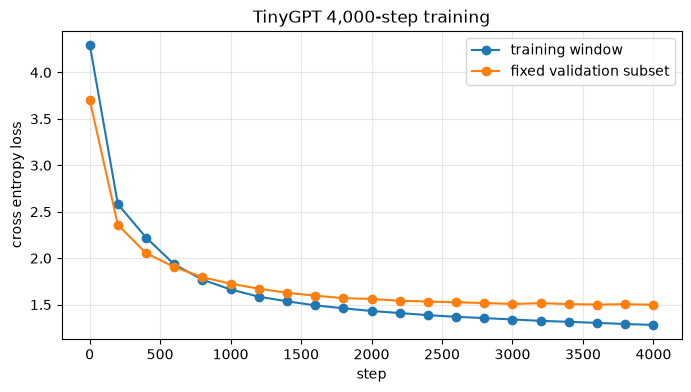

In [16]:
# 使用同一横轴比较训练与验证 loss 的变化趋势。
steps = [metric["step"] for metric in history]
training_losses = [
    metric["training_loss"]
    for metric in history
]
validation_subset_losses = [
    metric["validation_subset_loss"]
    for metric in history
]

plt.figure(figsize=(8, 4))
plt.plot(
    steps,
    training_losses,
    marker="o",
    label="training window",
)
plt.plot(
    steps,
    validation_subset_losses,
    marker="o",
    label="fixed validation subset",
)
plt.xlabel("step")
plt.ylabel("cross entropy loss")
plt.title("TinyGPT 4,000-step training")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 12. 生成文本

与阶段 1 保持相同：生成从一个换行 token 开始，不提供文本 prompt。`max_new_tokens=300` 会追加 300 个 token，返回结果还包含 1 个起始 token，因此共有 301 个 token。

TinyGPT 每一步使用最近最多 128 个 token 作为上下文。这里每次都会重新创建 generator，并设置同一个 seed。

模型权重、起始 token、生成参数和运行环境相同时，输出可以复现。生成使用独立的随机数生成器，因此不会改变训练使用的随机数序列。

In [17]:
generation_device = (
    "cuda" if device.type == "cuda" else "cpu"
)
# 使用独立且可复现的生成随机序列，不推进训练使用的随机状态。
generation_generator = torch.Generator(
    device=generation_device,
)
generation_generator.manual_seed(training_config.seed + 3)
# 从一个换行 token 开始自回归生成。
start_token_id = tokenizer.encode("\n")[0]
start_token = torch.tensor(
    [[start_token_id]],
    device=device,
)
generated_tokens = training_model.generate(
    start_token,
    max_new_tokens=300,
    generator=generation_generator,
)
generated_ids = generated_tokens[0].tolist()
generated_text = tokenizer.decode(generated_ids)

output_path = Path(
    "../outputs/tinygpt_notebook/generated.txt"
)
output_path.parent.mkdir(parents=True, exist_ok=True)
output_path.write_text(generated_text, encoding="utf-8")
print(generated_text)



The povertize of us, Lord of Hereford, England,
As thy house is the quiest of English caest,
Yet coldly we consuls our ignorance did emperate
Of our friends. I acquaint you, gentle Bridkendon,
That death he, or else you shall be thus gone.
Go obedience, the pretty of faults,
Did tell you, a royal m


该样本用于检查自回归生成链路，并与 Bigram 的单 token 上下文进行直观比较。生成质量不属于阶段 2 验收条件。

## 13. 模型参数量

当前配置为 `V_vocab=65`、最大位置数 `128`、`D=256`、4 个 block。

| 组件 | 计算式 | 参数量 |
| --- | ---: | ---: |
| Token embedding | `65 × 256` | 16,640 |
| Position embedding | `128 × 256` | 32,768 |
| 一个 block | 见下方 | 789,760 |
| 4 个 block | `4 × 789,760` | 3,159,040 |
| Final LayerNorm | `2 × 256` | 512 |
| LM head | `256 × 65` | 16,640 |

一个 block 包含：

```text
两个 LayerNorm   4D                         =   1,024
QKV Linear       D×3D + 3D                 = 197,376
Output Linear    D×D + D                   =  65,792
MLP              D×4D + 4D + 4D×D + D     = 525,568
                                                  -------
                                                  789,760
```

总参数量：

```text
16,640 + 32,768 + 3,159,040 + 512 + 16,640
= 3,225,600
```

Dropout、GELU 和 causal mask 没有可训练参数。固定 `D=256` 时，head 数量只改变 Q、K、V 的重排方式，不改变 QKV Linear 的参数量。

## 14. 阶段 2 验收问题

### 1. Token embedding 与 position embedding 分别提供什么信息？

> Token embedding 提供 token 身份相关的向量，position embedding 提供序列位置相关的向量。两者相加后，每个位置同时具有内容与位置信息。

### 2. Q、K、V 为什么从 `[B,T,D]` 变为 `[B,H,T,head_dim]`？

> QKV Linear 读取完整的 `D` 维输入，并分别产生 `D` 维的 Q、K、V。每个投影结果随后重排为 `H` 个 head，每个 head 的维度为 `head_dim=D/H`。

### 3. Attention scores 为什么是 `[B,H,T,T]`？

> 每个 batch、每个 head 中，T 个 query 分别与 T 个 key 做点积。一个分数对应一个 query-key 位置组合。

### 4. Causal mask 防止什么信息泄漏？

> 它阻止位置 `t` 读取 `t` 右侧的 token，保证模型预测下一个 token 时只能使用已经出现的上下文。

### 5. Residual connection 与 LayerNorm 分别起什么作用？

> Residual connection 保留子层输入并叠加新变化，为信息和梯度提供直接路径。LayerNorm 对每个位置的 `D` 个特征独立归一化，再应用可学习的缩放与偏移。它有助于控制 hidden-state 的数值尺度，并改善训练稳定性。

### 6. MLP 在哪个维度上工作？

> MLP 独立处理每个 batch、每个序列位置的特征向量，只变换最后一个特征维，形状经历 `D → 4D → D`。

### 7. 完整 forward 流程是什么？

> `input_ids → token/position embedding → 多层 causal attention 与 MLP → final LayerNorm → vocabulary logits → cross entropy loss`。